# Live demo : A ML Gaze Estimation Way to Predict Heatmap from Video
<br>

**🧩 What we need:**  
- A **web camera** to capture the user's face  🎥
- A **gaze estimation ML model** (e.g., MobilGaze or L2CS-Net)   💻 
- Some **Python scripts** for data processing   🐍
- And yes — a little **math** 😉  
<br>
---

<div style="display: flex; justify-content: space-between; align-items: flex-start; gap: 10px;">

  <!-- Mindmap -->
  <div style="text-align: center; flex: 1;">
    <img src="mindmap.gif" alt="Mindmap design" style="height:100%; max-width:450px; border-radius:10px;">
    <p><strong>Mindmap</strong><br>
    The new Mindmap experience design displayed on a 65-inch TV screen.</p>
  </div>

  <!-- Michael -->
  <div style="text-align: center; flex: 1;">
    <img src="./Miachel_gif.gif" alt="Michael watching" style="height:100%; max-width:450px; border-radius:10px;">
    <p><strong>User Video</strong><br>
    We recorded 10 seconds of Michael's gaze behavior.</p>
  </div>

  <!-- Calibration -->
  <div style="text-align: center; flex: 1;">
    <img src="./calibration.gif" alt="Calibration process" style="height:250px; max-width:450px; border-radius:10px;">
    <p><strong>Calibration Process</strong><br>
    During calibration, user followed a moving white dot with his eyes.</p>
  </div>

</div>


<br>

# <!-- 1. Inference the Gaze Direction from Video (simple layout) -->

<h2>1. 💡 Infer Gaze Direction from Video</h2>
<p>
  To determine what the participant is looking at in the recorded session, we run a lightweight
  <strong>gaze estimation</strong> ML model on the video. For a good balance of speed and accuracy, we use the
  pre-trained weights <code>resnet34.pt</code> from
  <a href="https://github.com/yakhyo/gaze-estimation?tab=readme-ov-file" target="_blank">yakhyo/gaze-estimation</a>,
  with a small tweak to the inference script to match our pipeline. 
</p>


In [157]:
!python inference.py --model resnet34 \
  --weight weights/resnet34.pt \
  --view \
  --source Michael_Example.mp4 \
  --output Michael_Example_output_00.mp4 \
  --angles Michael_Example_output_angles_00.csv

INFO: Initializing RetinaFace with model=RetinaFaceWeights.MNET_V2, conf_thresh=0.5, nms_thresh=0.4, pre_nms_topk=5000, post_nms_topk=750, dynamic_size=False, input_size=(640, 640)
INFO: Model 'RetinaFaceWeights.MNET_V2' already exists at /Users/macbook/.uniface/models/RetinaFaceWeights.MNET_V2.onnx
INFO: Verified model weights located at: /Users/macbook/.uniface/models/RetinaFaceWeights.MNET_V2.onnx
INFO: Successfully initialized the model from /Users/macbook/.uniface/models/RetinaFaceWeights.MNET_V2.onnx
INFO: Gaze Estimation model weights loaded.
INFO: Angles CSV: Michael_Example_output_angles_00.csv
^C_inference_collection.py", line 220, in run

KeyboardInterrupt


<table style="width:60%; border-collapse:collapse; border: none;">
  <tr style="border: none;">
    <td style="vertical-align:top; padding:8px; border: none;">
      <p>
        If everything goes well, we’ll generate an output video with the gaze direction prediction
        on each frame. The corresponding angle values will also be saved to a CSV file.
        <br>
        <br>
        <br>
        <br>
        <br>
        But, yes, normally we need to wait a looooooooong time. 🫠
      </p>
    </td>
    <td style="width:300px; text-align:right; vertical-align:middle; padding:8px; border: none;">
      <img src="waiting.gif" alt="Processing…" style="max-width:300px; height:auto;">
    </td>
  </tr>
</table>


In [158]:
import pandas as pd
df = pd.read_csv("Michael_Example_output_angles.csv")
df[['frame_idx', 'pitch_deg', 'yaw_deg']].iloc[1200:1210]

,frame_idx,pitch_deg,yaw_deg
1200,1200,-0.6313,13.4573
1201,1201,0.6429,13.6408
1202,1202,-0.2327,11.4398
1203,1203,-0.6978,12.1790
1204,1204,-0.1091,12.0580
1205,1205,-1.2722,13.1762
1206,1206,-0.2757,13.8180
1207,1207,-0.4403,13.8825
1208,1208,-0.3217,14.1844
1209,1209,-1.2761,12.7406



<table style="width:60%; border-collapse:collapse; border: none;">
  <tr style="border: none;">
    <td style="vertical-align:top; padding:8px; border: none;">
      <p>
        Unfortunately, the model won't be able to provide the 2D gaze data that we can directly use to produce the heatmap. Instead, the data it predicted is in the form of an arrow angle (yaw, pitch).<br><br> So our job is to post-process the data to map the in space arrow angle to the screen 2D gaze data. <br>
        <br>
        <br>
        <br>
        <br>
      </p>
    </td>
    <td style="width:300px; text-align:right; vertical-align:middle; padding:8px; border: none;">
      <img src="Michael_py_example.png" alt="Processing…" style="max-width:300px; height:auto;">
    </td>
  </tr>
</table>

---
<br>

# 2. 🎯 Time to use the Calibration Data

We ask the user to look at nine specific points — the corners, edges, and the center. Because we already know exactly where those points are as they are fixed on the screen, the 9-point helps us anchor how the user’s eye direction relates to actual positions on the screen. <br>


<div style="display: flex; justify-content: space-between; align-items: flex-start; gap: 10px;">

  <!-- Mindmap -->
  <div style="text-align: center; flex: 1;">
    <img src="./screen2cal.png" alt="Mindmap design" style="width:100%; max-width:500px; border-radius:10px;">
    <p><strong>Mapping process</strong><br>
    Calibration points helps us map users gaze angle to the screen position.</p>
  </div>

  <!-- Michael -->
  <div style="text-align: center; flex: 1;">
    <img src="./Michael_9.png" alt="Michael watching" style="width:100%; max-width:500px; border-radius:10px;">
    <p><strong>Calibration Data Frames</strong><br>
    We record and extract the frame that user looks at each of the 9 points.</p>
  </div>

  <!-- Calibration
  <div style="text-align: center; flex: 1;">
    <img src="./Miachel_gif.gif" alt="Calibration process" style="width:100%; max-width:300px; border-radius:10px;">
    <p><strong>Calibration Process</strong><br>
    During calibration, he followed a moving white dot with his eyes while keeping his head still.</p>
  </div> -->
</div>

### 🧪 Extract the 9 points data
But we need to firstly find those moments when the user were looking at each of those points in these long list of data. And then, since the user stays on each point for about 3–5 seconds, we can take several frames from that period and average them to get the most reliable result for each location. <br>

In [159]:
!python calc_calibration_stats.py \
--csv Michael_Example_output_angles.csv \
--window 18 \
--out Michael_calibration_frame.csv \
--middleFrames 49 151 254 356 460 563 666 769 974

   row  col  center_frame  n_frames  mean_pitch_deg  mean_yaw_deg
0    0    0            49        37         -6.1968       15.3262
1    1    0           151        37         -4.8080       10.3729
2    2    0           254        37         -3.9137        6.0281
3    2    1           356        37          9.1236        5.0166
4    2    2           460        37         18.4102        3.6635
5    1    2           563        37         19.5907        6.0160
6    0    2           666        37         16.7778        9.1825
7    0    1           769        37          6.2938       12.9489
8    1    1           974        37          8.7369       10.2235


---
<br>


## 3. 🏗️ Build a Mapping System (model) with the Calibration Data
<p align="center" ; border-radius: 10px;"> 
  <img src="./system_explain.png" width=100%> 
</p>
<br>
The function we are looking for is a second-order polynomial mapping function, which can be written as:
<br>

$$
f(pitch, yaw) = w_0 + w_1 ⋅ yaw + w_2 ⋅ pitch + w_3 ⋅ yaw^2 + w_4 ⋅ pitch^2 + w_5 ⋅ yaw ⋅ pitch
$$

<br>
We also want the system to be as accurate as possible, that means we need to find the best-fit coefficients
w_0 ... w_5 
of the function.
<br>



In a mathmatical way, we are looking for the matrix :

$$
\begin{bmatrix}
x_{\text{screen}} \\[3pt]
y_{\text{screen}}
\end{bmatrix}
=
\begin{bmatrix}
? & ? & ? & ? & ? & ? \\[3pt]
? & ? & ? & ? & ? & ?
\end{bmatrix}
\,
\begin{bmatrix}
1 \\[2pt]
\text{yaw} \\[2pt]
\text{pitch} \\[2pt]
\text{yaw}^2 \\[2pt]
\text{pitch}^2 \\[2pt]
\text{yaw}\,\text{pitch}
\end{bmatrix}
$$


Calibration data are the only things we can rely on to find those coefficients. 

<br>
Let's firstly fit the calibration model with LOO (Leave One Out) method roughly without any tuning.
LLO method means that every time we leave one calibration point out and use the other 8 to predict it. We do this 9 times and then average the results.

/Users/macbook/Desktop/Samsung/VD/usertest/gaze-estimation/fit_gaze_poly.py:96: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_x_i = float(Phi[~keep] @ w_x_k)
/Users/macbook/Desktop/Samsung/VD/usertest/gaze-estimation/fit_gaze_poly.py:97: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_y_i = float(Phi[~keep] @ w_y_k)

=== Weighted Polynomial Ridge Fit ===
File: Michael_calibration_frame.csv
Weighted: True   lambda: 1.0
R^2_x: 0.9913   R^2_y: 0.9089
LOO   |x-error|: {'median': 0.05680807383662889, 'mean': 0.07200253797576354, 'max': 0.13299775272269088, 'p90': 0.12915948496009594}
LOO   |y-error|: {'median': 0.1744068285907071, 'mea

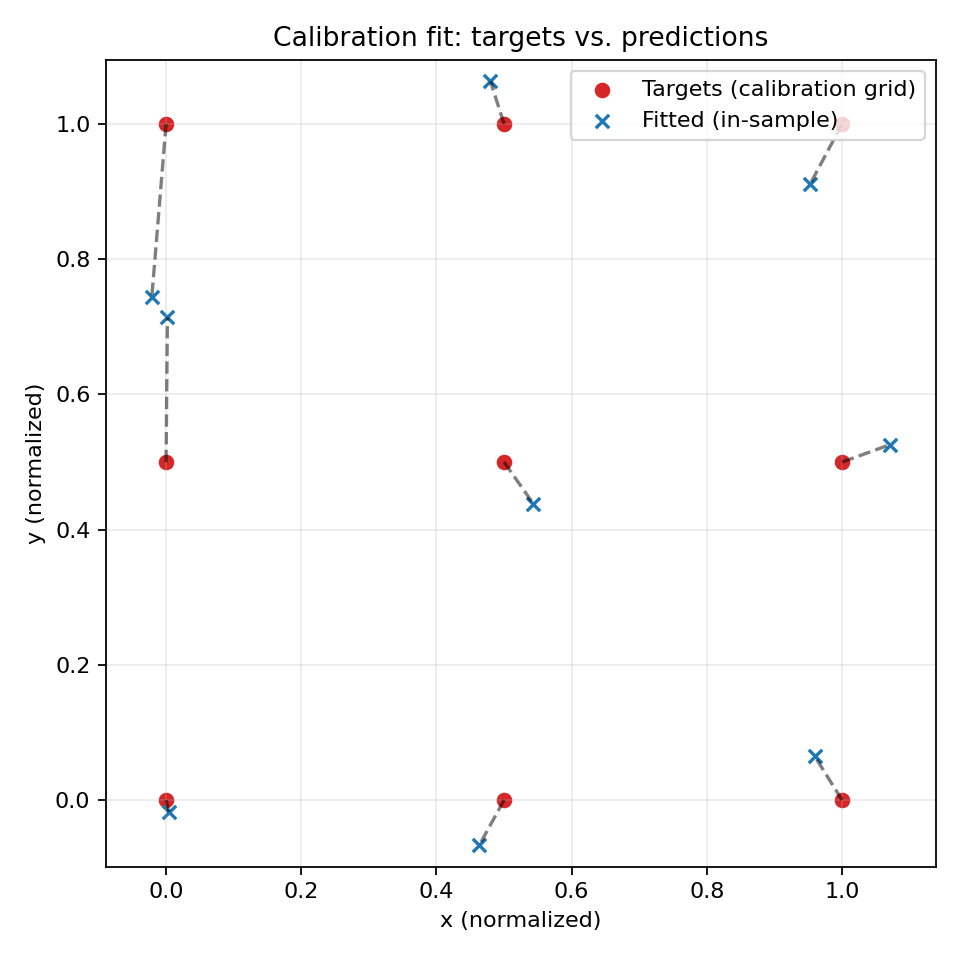

In [160]:
!python fit_gaze_poly.py \
  --csv Michael_calibration_frame.csv \
  --out Michael_regression_model.json \
  --lam 1 \
  --weighted 1 \
  --plot 1 \
  --plot-out Michael_calibration_fit_01.png
  
from IPython.display import Image, display
display(Image(filename="Michael_calibration_fit_01.png",width=400))

This doesn't look good, does it? Some points are far away from the actual screen position. Which means the screen in the prediction is very twisted.<br>


<div style="display: flex; justify-content: space-between; align-items: flex-start; gap: 10px;">

  <!-- Mindmap -->
  <div style="text-align: center; flex: 1;">
    <img src="./michael_layout (1).png" alt="Mindmap design" style="width:100%; max-width:600px; border-radius:10px;">
    <p><strong>Oringinal Screen</strong><br>
  </div>

  <!-- Michael -->
  <div style="text-align: center; flex: 1;">
    <img src="./example_twist_layout1.png" alt="Michael watching" style="width:100%; max-width:600px; border-radius:10px;">
    <p><strong>Twisted Screen in the prediction</strong><br>
  </div>

  <!-- Calibration
  <div style="text-align: center; flex: 1;">
    <img src="./Miachel_gif.gif" alt="Calibration process" style="width:100%; max-width:300px; border-radius:10px;">
    <p><strong>Calibration Process</strong><br>
    During calibration, he followed a moving white dot with his eyes while keeping his head still.</p>
  </div> -->
</div>

### 🛠️ Tuning the parameters to get the best model

==== Lambda Tuning Complete ====
Best lambda: 0.019306977288832496
Scoring weights: x_weight=0.5, y_weight=2.5
Score (x_weight*x_mean + y_weight*y_mean): 0.5791675226657562
Final model: Michael_regression_model_lam0.019306977288832496.json
Summary CSV: lambda_search/Michael_regression_model_lambda_search_summary.csv
Report: lambda_search/Michael_regression_model_best.txt
Replay script: lambda_search/Michael_regression_model_replay_best.sh


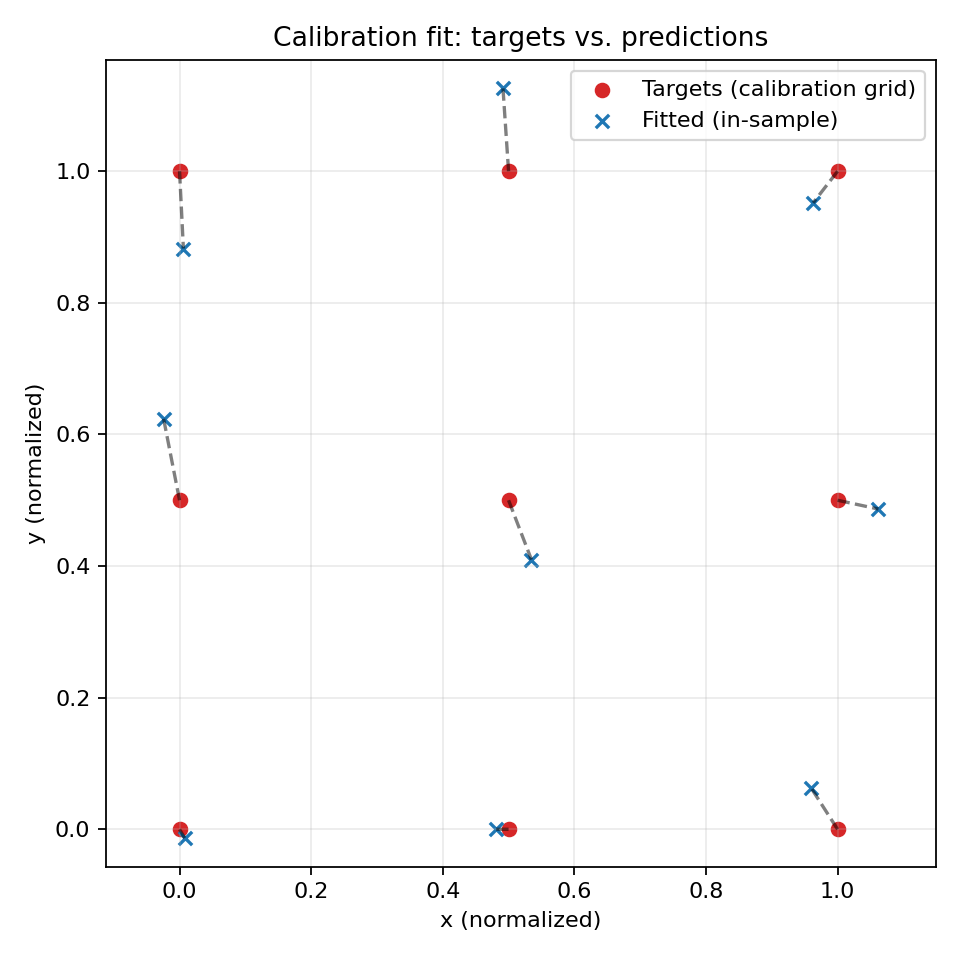

In [161]:
!python tune_lambda.py \
  --csv Michael_calibration_frame.csv \
  --out-prefix Michael_regression_model \
  --weighted 1 \
  --plot-best 1 \
  --x-weight 0.5 --y-weight 2.5 \
  --extra-args "--plot-out lambda_search/plots/Michael_regression_model_best.png --show-plot 0"
display(Image(filename="lambda_search/plots/Michael_regression_model_best.png",width=400))

This times it looks better.<br>


<div style="display: flex; justify-content: space-between; align-items: flex-start; gap: 10px;">

  <!-- Mindmap -->
  <div style="text-align: center; flex: 1;">
    <img src="./example_twist_layout1.png" alt="Mindmap design" style="width:100%; max-width:600px; border-radius:10px;">
    <p><strong>Result before tuning</strong><br>
  </div>

  <!-- Michael -->
  <div style="text-align: center; flex: 1;">
    <img src="./example_twist_layout2.png" alt="Michael watching" style="width:100%; max-width:600px; border-radius:10px;">
    <p><strong>Result after tuning regularization parameter</strong><br>
  </div>

  <!-- Calibration
  <div style="text-align: center; flex: 1;">
    <img src="./Miachel_gif.gif" alt="Calibration process" style="width:100%; max-width:300px; border-radius:10px;">
    <p><strong>Calibration Process</strong><br>
    During calibration, he followed a moving white dot with his eyes while keeping his head still.</p>
  </div> -->
</div>

<p align="center" style="border-radius: 10px;"> 
  <img src="./acceptable.gif" alt="Michael watching" style="width:20%; max-width:600px; border-radius:10px;">
</p>

### 🥹 And we have the system ready!

In [162]:
!python fit_gaze_poly.py \
 --csv "Michael_calibration_frame.csv" \
 --out "Michael_best_model.json" \
 --lam 0.019306977288832496 \
 --weighted 1 \
 --plot 1 \
 --plot-out Michael_best_model.png \
 --show-plot 0

/Users/macbook/Desktop/Samsung/VD/usertest/gaze-estimation/fit_gaze_poly.py:96: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_x_i = float(Phi[~keep] @ w_x_k)
/Users/macbook/Desktop/Samsung/VD/usertest/gaze-estimation/fit_gaze_poly.py:97: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_y_i = float(Phi[~keep] @ w_y_k)

=== Weighted Polynomial Ridge Fit ===
File: Michael_calibration_frame.csv
Weighted: True   lambda: 0.019306977288832496
R^2_x: 0.9939   R^2_y: 0.9602
LOO   |x-error|: {'median': 0.07769726879438943, 'mean': 0.07379970468266651, 'max': 0.12154941727104407, 'p90': 0.1164664051664149}
LOO   |y-error|: {'median': 0.179689

In [163]:
import json
from IPython.display import JSON, display

with open("Michael_best_model.json", "r") as f:
    obj = json.load(f)

display(JSON(obj)) 

<IPython.core.display.JSON object>

We found the things (coefficients) we wnat :

$$
\begin{bmatrix}
x_{\text{screen}} \\[3pt]
y_{\text{screen}}
\end{bmatrix}
=
\begin{bmatrix}
0.2231 & -0.0274 & 0.0272 & 0.00193 & 0.00071 & 0.00112 \\[3pt]
0.9723 & 0.0614 & 0.0684 & -0.00893 & -0.00263 & -0.00732
\end{bmatrix}
\,
\begin{bmatrix}
1 \\[2pt]
\text{yaw} \\[2pt]
\text{pitch} \\[2pt]
\text{yaw}^2 \\[2pt]
\text{pitch}^2 \\[2pt]
\text{yaw}\,\text{pitch}
\end{bmatrix}
$$


## 4. 📝 Predict the other gaze data!
<br>
Once we get the system ready, we can feed all the data to the system and get the fact of each frame where Michael was looking at.

In [164]:
!python test_predict.py \
--in_csv Michael_Example_output_angles.csv \
--model_json Michael_best_model.json \
--frame_start 1028 \
--frame_end 1342 \
--smoothing ema \
--out_csv "Michael_predict_output.csv"

df = pd.read_csv("Michael_predict_output.csv")
df[['frame_idx', 'pitch_deg', 'yaw_deg', 'x_norm', 'y_norm']].iloc[215:225]

Saved: /Users/macbook/Desktop/Samsung/VD/usertest/gaze-estimation/Michael_predict_output.csv


,frame_idx,pitch_deg,yaw_deg,x_norm,y_norm
215,1243,11.9671,9.3224,0.685262,0.393996
216,1244,11.6195,9.0154,0.660019,0.473040
217,1245,12.2904,9.3347,0.703212,0.371021
218,1246,12.3967,9.2273,0.706679,0.385082
219,1247,12.0273,9.3101,0.688274,0.392581
220,1248,12.3690,8.2460,0.685506,0.568586
221,1249,11.8904,8.3437,0.661651,0.578293
222,1250,11.7268,10.3225,0.695714,0.209044
223,1251,12.3180,9.6794,0.712635,0.300791
224,1252,12.8004,11.5646,0.791850,0.000000


# 5. FINALLY!!! Plot the heatmap!

Yea, it's hard to believe but ploting the heatmap is actually the easiest part of this project.<br>
We used the Kernel Density Estimation heatmap to visualize the result which show how densely data points are distributed in space — a smoothed version of a scatter plot.

[OK] Saved to Michael_exmaple_heatmap.png


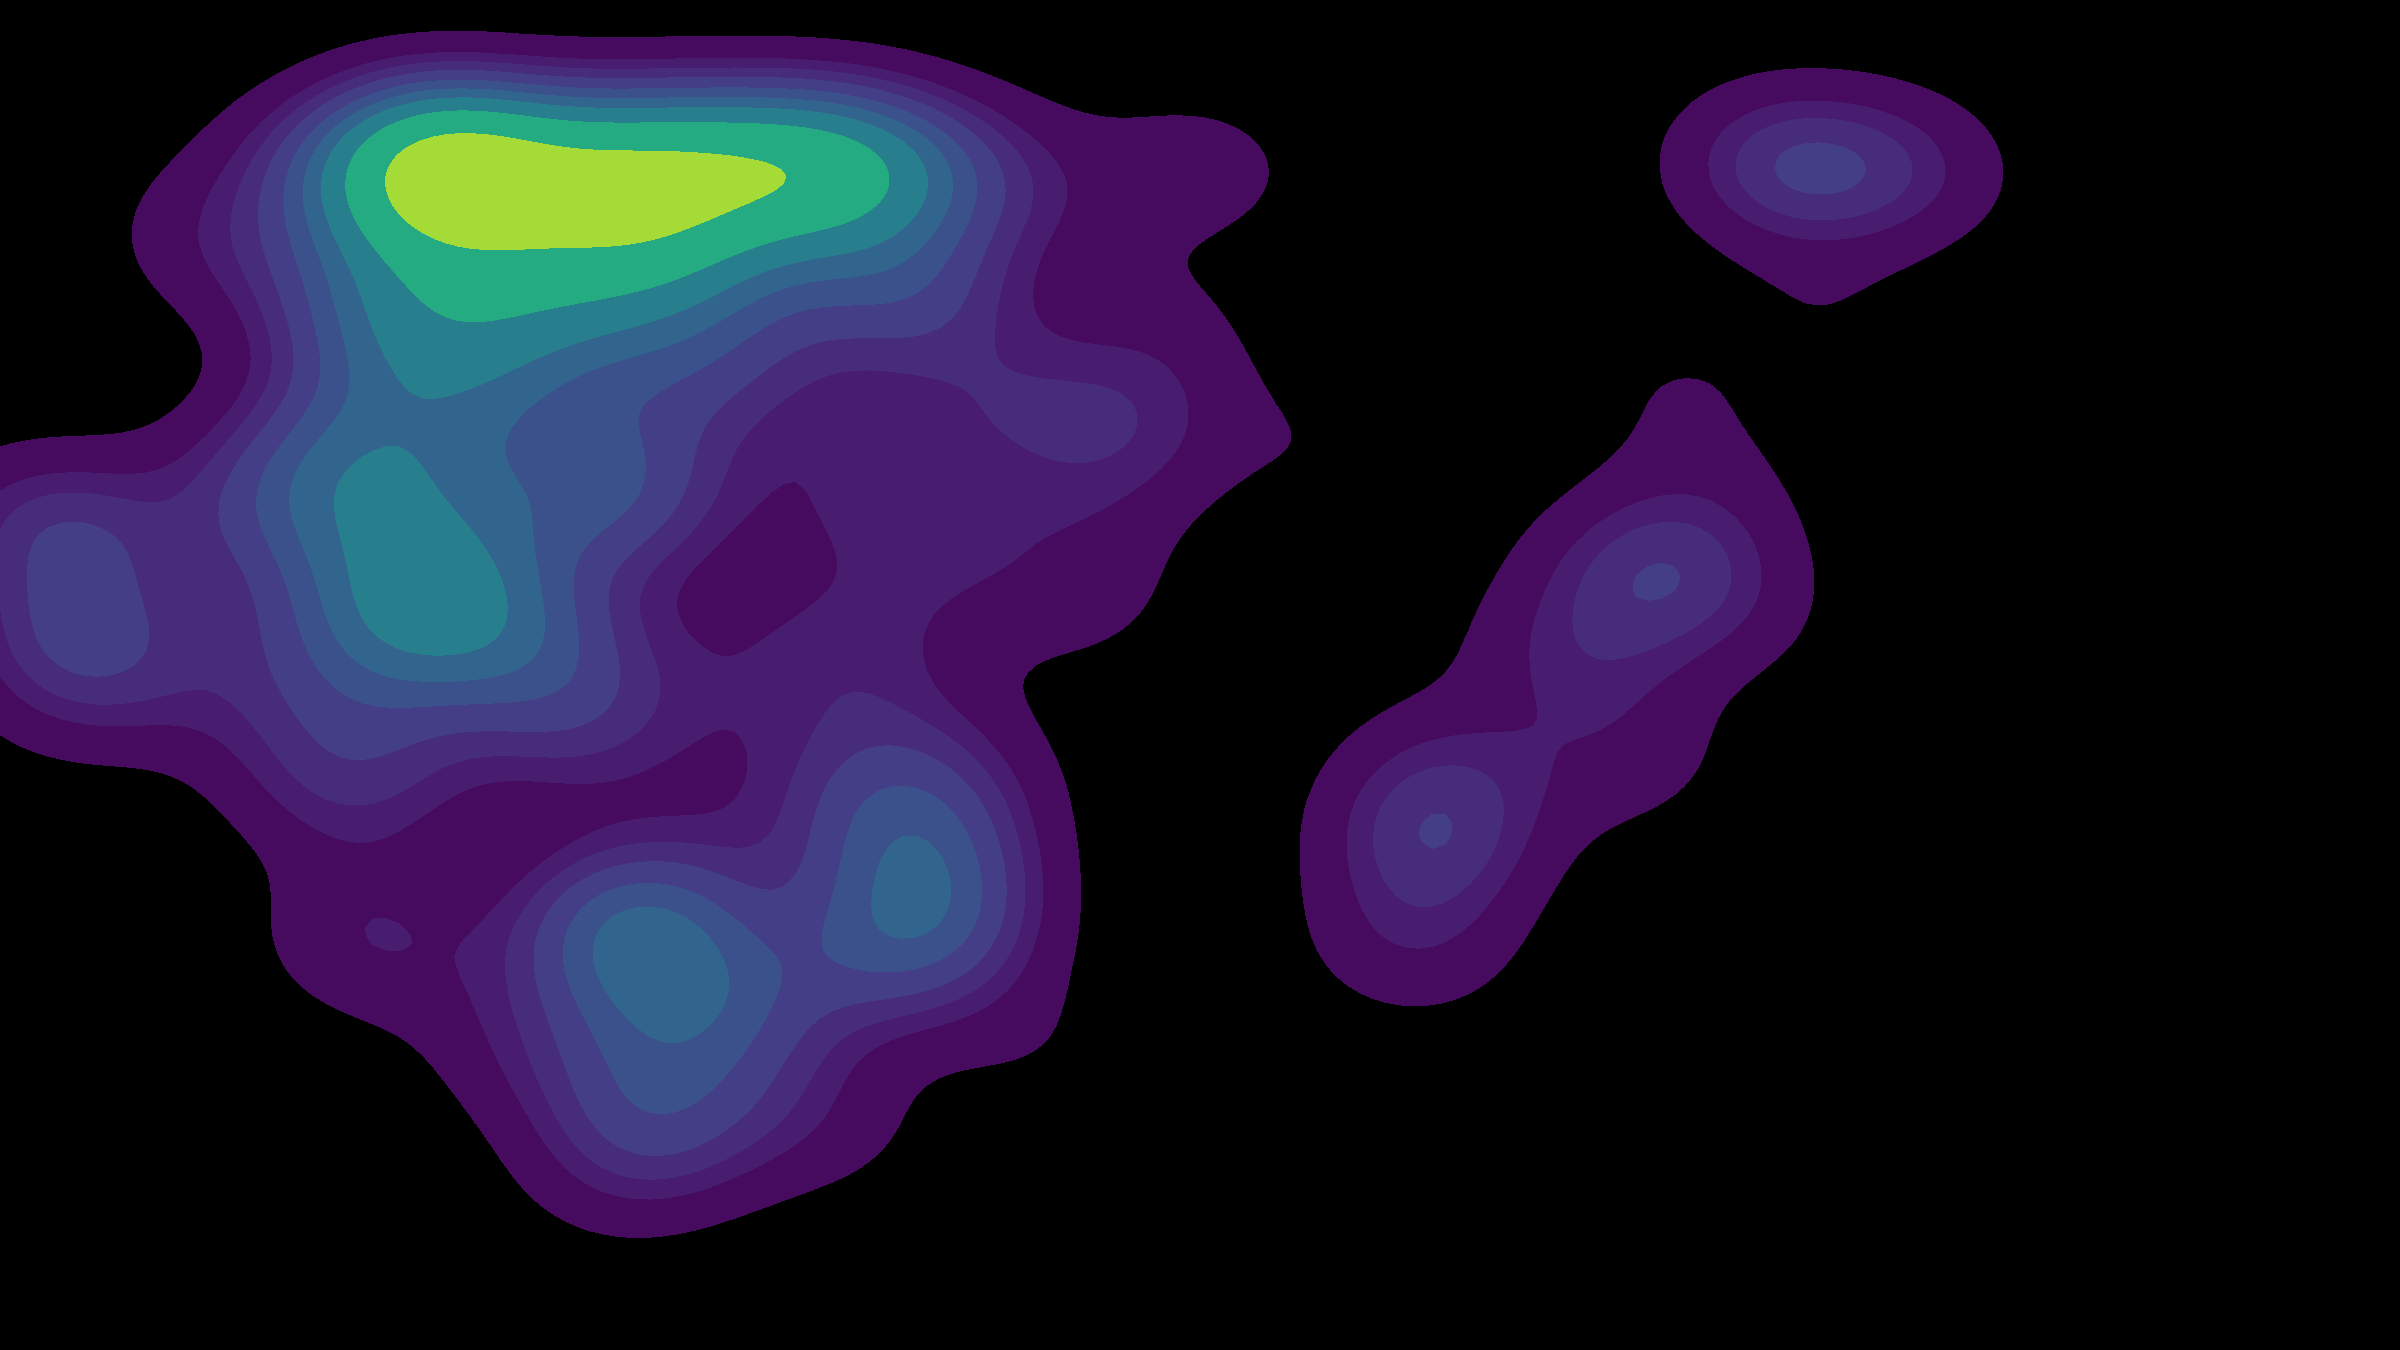

In [165]:
!python gaze_kde.py \
--csv Michael_predict_output.csv \
--out Michael_exmaple_heatmap.png

display(Image(filename="Michael_exmaple_heatmap.png",width=600))

### Put it on the screen
<p align="center" style="background-color:rgb(30, 31, 36); border-radius: 10px;"> 
  <img src="./Michael_layout.png" width="900"> 
</p>